# 🏗️ 07 — Model 5: Hybrid CNN-Attention + Ablation Study

**Innovation:** ResNet50 + CBAM (Convolutional Block Attention Module)
- **Channel attention:** which feature maps matter?
- **Spatial attention:** which spatial regions matter?

**Ablation study:** compare backbone-only vs backbone+channel-only vs full CBAM.

In [1]:
from pathlib import Path
from collections import defaultdict
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

CLASSES = ['plastic', 'paper_cardboard', 'metal', 'glass', 'organic', 'e_waste']
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

IMG_SIZE = 224
BATCH_SIZE = 4
NUM_WORKERS = 0
SEED = 42

PROJECT_ROOT = Path(r'C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification')
DATA_DIR = PROJECT_ROOT / 'notebooks' / 'data'
PROC_DIR = DATA_DIR / 'processed'
CKPT_DIR = PROJECT_ROOT / 'checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=30),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.2)),
])

val_test_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False

class WasteDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = Path(root_dir)
        self.transform = transform
        self.samples = []
        for cls in CLASSES:
            cls_dir = self.root / cls
            if not cls_dir.exists():
                continue
            for img_path in sorted(cls_dir.glob('*.jpg')):
                self.samples.append((img_path, CLASS_TO_IDX[cls]))
        self.targets = [s[1] for s in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

    def class_counts(self):
        counts = defaultdict(int)
        for _, label in self.samples:
            counts[IDX_TO_CLASS[label]] += 1
        return dict(counts)

def get_dataloaders(proc_dir=PROC_DIR, train_tfm=None, val_tfm=None, batch_size=BATCH_SIZE):
    train_ds = WasteDataset(Path(proc_dir) / 'train', train_tfm)
    val_ds = WasteDataset(Path(proc_dir) / 'val', val_tfm)
    test_ds = WasteDataset(Path(proc_dir) / 'test', val_tfm)

    if len(train_ds) == 0:
        raise ValueError(f'No training images found in {Path(proc_dir) / "train"}')

    counts = np.bincount(train_ds.targets, minlength=NUM_CLASSES)
    weights = 1.0 / (counts[train_ds.targets] + 1e-6)
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

    kw = dict(num_workers=0, pin_memory=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, **kw)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, **kw)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, **kw)

    print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')
    return train_loader, val_loader, test_loader

class EarlyStopping:
    def __init__(self, patience=7, delta=1e-4):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

def train_model(model, model_name, train_loader, val_loader, num_epochs=30, lr=1e-3, weight_decay=1e-4, scheduler_type='cosine', label_smoothing=0.1, device=None):
    if device is None:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

    if scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    elif scheduler_type == 'onecycle':
        scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=num_epochs)
    else:
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    early_stop = EarlyStopping(patience=7)
    best_val_acc = 0.0
    history = {k: [] for k in ('train_loss', 'val_loss', 'train_acc', 'val_acc')}

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n{"="*60}', flush=True)
    print(f'Model : {model_name}', flush=True)
    print(f'Params: {trainable:,} | Device: {device} | Batch size: {train_loader.batch_size}', flush=True)
    print(f'{"="*60}', flush=True)

    for epoch in range(1, num_epochs + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for batch_idx, (imgs, labels) in enumerate(train_loader, start=1):
            print(f'  Epoch {epoch:3d}/{num_epochs} | batch {batch_idx:3d}/{len(train_loader)} | loaded', flush=True)
            imgs = imgs.to(device, non_blocking=False)
            labels = labels.to(device, non_blocking=False)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                out = model(imgs)
                loss = criterion(out, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            if scheduler_type == 'onecycle':
                scheduler.step()
            run_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)
            print(f'  Epoch {epoch:3d}/{num_epochs} | batch {batch_idx:3d}/{len(train_loader)} | loss {loss.item():.4f}', flush=True)

        t_loss = run_loss / total
        t_acc = correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device, non_blocking=False)
                labels = labels.to(device, non_blocking=False)
                with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                    out = model(imgs)
                    loss = criterion(out, labels)
                v_loss += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total += imgs.size(0)

        v_loss /= v_total
        v_acc = v_correct / v_total

        if scheduler_type != 'onecycle':
            scheduler.step()

        for key, value in zip(history, [t_loss, v_loss, t_acc, v_acc]):
            history[key].append(value)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            CKPT_DIR.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), CKPT_DIR / f'{model_name}_best.pth')

        print(f'Epoch {epoch:3d}/{num_epochs} | Train {t_loss:.4f}/{t_acc:.3f} | Val {v_loss:.4f}/{v_acc:.3f}', flush=True)

        early_stop(v_loss)
        if early_stop.early_stop:
            print(f'Early stopping at epoch {epoch}', flush=True)
            break

    history['best_val_acc'] = best_val_acc
    print(f'Best val acc: {best_val_acc:.4f}', flush=True)
    return history

def evaluate_model(model, model_name, test_loader, device=None):
    if device is None:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    ckpt = CKPT_DIR / f'{model_name}_best.pth'
    if ckpt.exists():
        model.load_state_dict(torch.load(ckpt, map_location=device))
        print(f'Loaded checkpoint: {ckpt.name}')

    model.eval().to(device)
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            out = model(imgs.to(device))
            probs = torch.softmax(out, 1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print(f'\n{model_name} - Test Results')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {p:.4f} Recall: {r:.4f} F1: {f1:.4f}')
    print('\nPer-class report:')
    print(classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0))

    return dict(model=model_name, accuracy=acc, precision=p, recall=r, f1=f1, confusion_matrix=cm, preds=all_preds, labels=all_labels, probs=all_probs)

def plot_training_curves(history, model_name, save=True):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
    ax1.plot(epochs, history['val_loss'], 'r-o', ms=3, label='Val')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax2.plot(epochs, history['train_acc'], 'b-o', ms=3, label='Train')
    ax2.plot(epochs, history['val_acc'], 'r-o', ms=3, label='Val')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(alpha=0.3)
    plt.suptitle(model_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(FIGURES_DIR / f'curves_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(cm, model_name, save=True):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if save:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(FIGURES_DIR / f'cm_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

class EfficientNetModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )

    def freeze_backbone(self):
        for param in self.backbone.features.parameters():
            param.requires_grad = False

    def unfreeze_all(self):
        for param in self.backbone.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

set_seed()
if not torch.cuda.is_available():
    raise RuntimeError('CUDA GPU is not available in this notebook kernel.')
DEVICE = torch.device('cuda:0')
torch.backends.cudnn.benchmark = True
print(f'Device: {DEVICE} - {torch.cuda.get_device_name(0)}')
print(f'Using data: {PROC_DIR}')

train_loader, val_loader, test_loader = get_dataloaders(
    proc_dir=PROC_DIR,
    train_tfm=train_transforms,
    val_tfm=val_test_transforms,
)

Device: cuda:0 - NVIDIA GeForce RTX 3070 Laptop GPU
Using data: C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification\notebooks\data\processed
Train: 1,888 | Val: 401 | Test: 412


In [2]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=(2, 3), keepdim=True)
        mx = torch.amax(x, dim=(2, 3), keepdim=True)
        return self.sigmoid(self.mlp(avg) + self.mlp(mx)) * x

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx = torch.amax(x, dim=1, keepdim=True)
        attn = self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return attn * x

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention()

    def forward(self, x):
        x = self.channel_attn(x)
        x = self.spatial_attn(x)
        return x

class HybridCNNAttention(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        backbone = models.resnet50(weights='IMAGENET1K_V2')
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.attn1 = CBAM(256)
        self.attn2 = CBAM(512)
        self.attn3 = CBAM(1024)
        self.attn4 = CBAM(2048)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2048, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.attn1(self.layer1(x))
        x = self.attn2(self.layer2(x))
        x = self.attn3(self.layer3(x))
        x = self.attn4(self.layer4(x))
        return self.head(self.pool(x).flatten(1))

print('Loading ResNet50 + CBAM hybrid model...', flush=True)
model = HybridCNNAttention().to(DEVICE)
print('Hybrid model loaded.', flush=True)
print(f'Model device: {next(model.parameters()).device}')
print(f'Total params: {sum(p.numel() for p in model.parameters()):,}')

Loading ResNet50 + CBAM hybrid model...
Hybrid model loaded.
Model device: cuda:0
Total params: 24,217,038


In [3]:
# Stage 1: CBAM modules + head only (backbone frozen)
for name, p in model.named_parameters():
    p.requires_grad = 'attn' in name or 'head' in name
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 1 trainable: {trainable:,}')
h1 = train_model(model,'hybrid_s1',train_loader,val_loader,num_epochs=5,lr=1e-3,device=DEVICE)

Stage 1 trainable: 709,006

Model : hybrid_s1
Params: 709,006 | Device: cuda:0 | Batch size: 4


  Epoch   1/5 | batch   1/472 | loaded


C:\Users\msfir\AppData\Local\Temp\ipykernel_41596\872370804.py:139: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
C:\Users\msfir\AppData\Local\Temp\ipykernel_41596\872370804.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


  Epoch   1/5 | batch   1/472 | loss 1.7900
  Epoch   1/5 | batch   2/472 | loaded
  Epoch   1/5 | batch   2/472 | loss 1.7827
  Epoch   1/5 | batch   3/472 | loaded
  Epoch   1/5 | batch   3/472 | loss 1.7957
  Epoch   1/5 | batch   4/472 | loaded
  Epoch   1/5 | batch   4/472 | loss 1.7755
  Epoch   1/5 | batch   5/472 | loaded
  Epoch   1/5 | batch   5/472 | loss 1.7979
  Epoch   1/5 | batch   6/472 | loaded
  Epoch   1/5 | batch   6/472 | loss 1.7676
  Epoch   1/5 | batch   7/472 | loaded
  Epoch   1/5 | batch   7/472 | loss 1.7894
  Epoch   1/5 | batch   8/472 | loaded
  Epoch   1/5 | batch   8/472 | loss 1.7907
  Epoch   1/5 | batch   9/472 | loaded
  Epoch   1/5 | batch   9/472 | loss 1.8102
  Epoch   1/5 | batch  10/472 | loaded
  Epoch   1/5 | batch  10/472 | loss 1.7955
  Epoch   1/5 | batch  11/472 | loaded
  Epoch   1/5 | batch  11/472 | loss 1.7973
  Epoch   1/5 | batch  12/472 | loaded
  Epoch   1/5 | batch  12/472 | loss 1.7990
  Epoch   1/5 | batch  13/472 | loaded
  Ep

C:\Users\msfir\AppData\Local\Temp\ipykernel_41596\872370804.py:193: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


Epoch   1/5 | Train 1.7922/0.159 | Val 1.7892/0.162
  Epoch   2/5 | batch   1/472 | loaded
  Epoch   2/5 | batch   1/472 | loss 1.7942
  Epoch   2/5 | batch   2/472 | loaded
  Epoch   2/5 | batch   2/472 | loss 1.7812
  Epoch   2/5 | batch   3/472 | loaded
  Epoch   2/5 | batch   3/472 | loss 1.8010
  Epoch   2/5 | batch   4/472 | loaded
  Epoch   2/5 | batch   4/472 | loss 1.7751
  Epoch   2/5 | batch   5/472 | loaded
  Epoch   2/5 | batch   5/472 | loss 1.7927
  Epoch   2/5 | batch   6/472 | loaded
  Epoch   2/5 | batch   6/472 | loss 1.7735
  Epoch   2/5 | batch   7/472 | loaded
  Epoch   2/5 | batch   7/472 | loss 1.7907
  Epoch   2/5 | batch   8/472 | loaded
  Epoch   2/5 | batch   8/472 | loss 1.7781
  Epoch   2/5 | batch   9/472 | loaded
  Epoch   2/5 | batch   9/472 | loss 1.7848
  Epoch   2/5 | batch  10/472 | loaded
  Epoch   2/5 | batch  10/472 | loss 1.7979
  Epoch   2/5 | batch  11/472 | loaded
  Epoch   2/5 | batch  11/472 | loss 1.8151
  Epoch   2/5 | batch  12/472 | loa


Model : hybrid_cnn_attention
Params: 24,217,038 | Device: cuda:0 | Batch size: 4


  Epoch   1/25 | batch   1/472 | loaded


C:\Users\msfir\AppData\Local\Temp\ipykernel_41596\872370804.py:139: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
C:\Users\msfir\AppData\Local\Temp\ipykernel_41596\872370804.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


  Epoch   1/25 | batch   1/472 | loss 1.7603
  Epoch   1/25 | batch   2/472 | loaded
  Epoch   1/25 | batch   2/472 | loss 1.8053
  Epoch   1/25 | batch   3/472 | loaded
  Epoch   1/25 | batch   3/472 | loss 1.8028
  Epoch   1/25 | batch   4/472 | loaded
  Epoch   1/25 | batch   4/472 | loss 1.7745
  Epoch   1/25 | batch   5/472 | loaded
  Epoch   1/25 | batch   5/472 | loss 1.7915
  Epoch   1/25 | batch   6/472 | loaded
  Epoch   1/25 | batch   6/472 | loss 1.8781
  Epoch   1/25 | batch   7/472 | loaded
  Epoch   1/25 | batch   7/472 | loss 1.7678
  Epoch   1/25 | batch   8/472 | loaded
  Epoch   1/25 | batch   8/472 | loss 1.7237
  Epoch   1/25 | batch   9/472 | loaded
  Epoch   1/25 | batch   9/472 | loss 1.8074
  Epoch   1/25 | batch  10/472 | loaded
  Epoch   1/25 | batch  10/472 | loss 1.7370
  Epoch   1/25 | batch  11/472 | loaded
  Epoch   1/25 | batch  11/472 | loss 1.8837
  Epoch   1/25 | batch  12/472 | loaded
  Epoch   1/25 | batch  12/472 | loss 1.7622
  Epoch   1/25 | bat

C:\Users\msfir\AppData\Local\Temp\ipykernel_41596\872370804.py:193: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


Epoch   1/25 | Train 1.8195/0.162 | Val 1.7915/0.160
  Epoch   2/25 | batch   1/472 | loaded
  Epoch   2/25 | batch   1/472 | loss 1.8668
  Epoch   2/25 | batch   2/472 | loaded
  Epoch   2/25 | batch   2/472 | loss 1.7617
  Epoch   2/25 | batch   3/472 | loaded
  Epoch   2/25 | batch   3/472 | loss 1.9137
  Epoch   2/25 | batch   4/472 | loaded
  Epoch   2/25 | batch   4/472 | loss 1.8027
  Epoch   2/25 | batch   5/472 | loaded
  Epoch   2/25 | batch   5/472 | loss 1.7747
  Epoch   2/25 | batch   6/472 | loaded
  Epoch   2/25 | batch   6/472 | loss 1.7714
  Epoch   2/25 | batch   7/472 | loaded
  Epoch   2/25 | batch   7/472 | loss 1.6526
  Epoch   2/25 | batch   8/472 | loaded
  Epoch   2/25 | batch   8/472 | loss 1.8476
  Epoch   2/25 | batch   9/472 | loaded
  Epoch   2/25 | batch   9/472 | loss 1.5950
  Epoch   2/25 | batch  10/472 | loaded
  Epoch   2/25 | batch  10/472 | loss 1.8652
  Epoch   2/25 | batch  11/472 | loaded
  Epoch   2/25 | batch  11/472 | loss 1.6473
  Epoch   2/

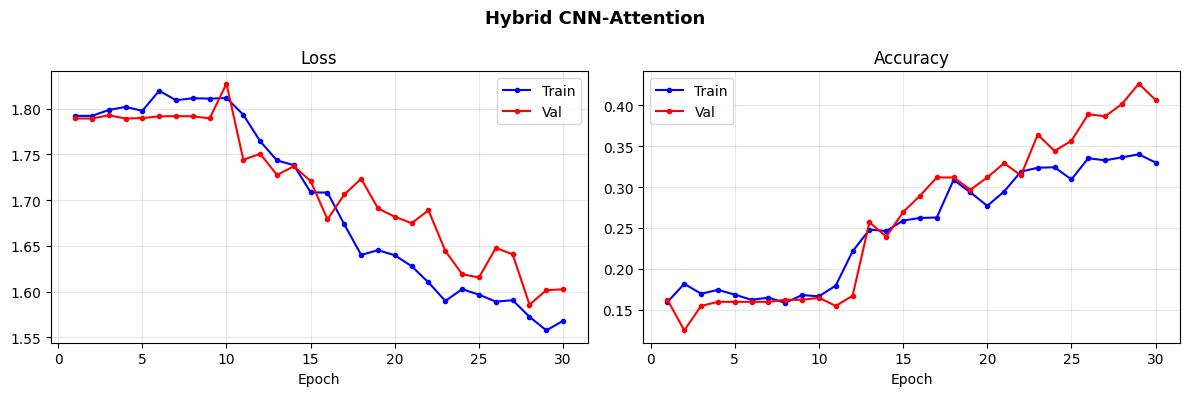

In [4]:
# Stage 2: full fine-tune
for p in model.parameters(): p.requires_grad = True
h2 = train_model(model,'hybrid_cnn_attention',train_loader,val_loader,
                 num_epochs=25,lr=5e-5,scheduler_type='cosine',device=DEVICE)
full = {k: h1[k]+h2[k] for k in ('train_loss','val_loss','train_acc','val_acc')}
plot_training_curves(full,'Hybrid CNN-Attention')

C:\Users\msfir\AppData\Local\Temp\ipykernel_41596\872370804.py:231: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=device)

Loaded checkpoint: hybrid_cnn_attention_best.pth

hybrid_cnn_attention - Test Results
Accuracy : 0.4078
Precision: 0.3867 Recall: 0.4078 F1: 0.3663

Per-class report:
                 precision    recall  f1-score   support

        plastic       0.42      0.38      0.40        66
paper_cardboard       0.46      0.67      0.54       136
          metal       0.47      0.11      0.18        72
          glass       0.00      0.00      0.00        71
        organic       0.09      0.50      0.16        14
        e_waste       0.65      0.70      0.67        53

       accuracy                           0.41       412
      macro avg       0.35      0.39      0.33       412
   weighted avg       0.39      0.41      0.37       412



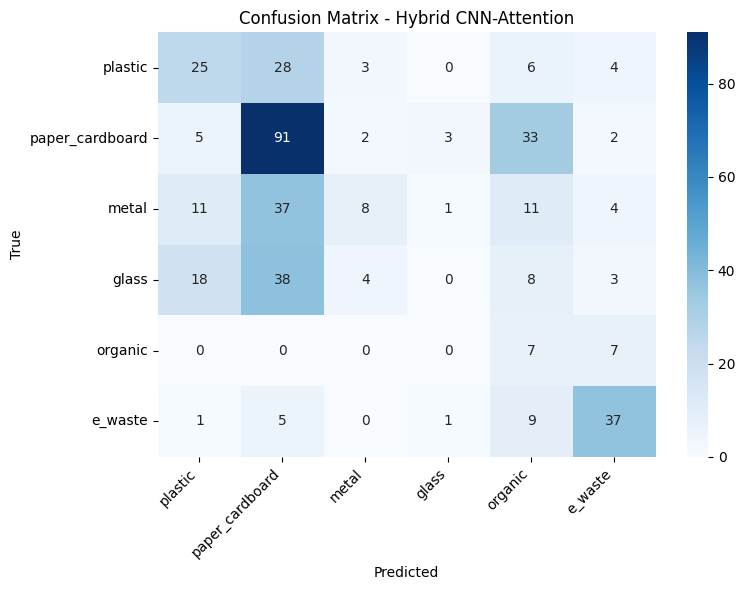

In [5]:
results = evaluate_model(model,'hybrid_cnn_attention',test_loader,device=DEVICE)
plot_confusion_matrix(results['confusion_matrix'],'Hybrid CNN-Attention')

In [6]:
resnet_plain = models.resnet50(weights='IMAGENET1K_V2')
resnet_plain.fc = nn.Linear(resnet_plain.fc.in_features, NUM_CLASSES)
h_plain = train_model(
    resnet_plain, 'resnet50_plain',
    train_loader, val_loader,
    num_epochs=15, lr=5e-5,
    scheduler_type='cosine',
    device=DEVICE
)
res_plain = evaluate_model(resnet_plain, 'resnet50_plain', test_loader, device=DEVICE)
print(f'\nAblation - ResNet50 (no CBAM): F1={res_plain["f1"]:.4f}')
print(f'Ablation - ResNet50 + CBAM:    F1={results["f1"]:.4f}')
print(f'CBAM improvement: {(results["f1"] - res_plain["f1"]) * 100:+.2f}%')


Model : resnet50_plain
Params: 23,520,326 | Device: cuda:0 | Batch size: 4
  Epoch   1/15 | batch   1/472 | loaded
  Epoch   1/15 | batch   1/472 | loss 1.6703
  Epoch   1/15 | batch   2/472 | loaded


C:\Users\msfir\AppData\Local\Temp\ipykernel_41596\872370804.py:139: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
C:\Users\msfir\AppData\Local\Temp\ipykernel_41596\872370804.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


  Epoch   1/15 | batch   2/472 | loss 1.8277
  Epoch   1/15 | batch   3/472 | loaded
  Epoch   1/15 | batch   3/472 | loss 1.7637
  Epoch   1/15 | batch   4/472 | loaded
  Epoch   1/15 | batch   4/472 | loss 1.8092
  Epoch   1/15 | batch   5/472 | loaded
  Epoch   1/15 | batch   5/472 | loss 1.7945
  Epoch   1/15 | batch   6/472 | loaded
  Epoch   1/15 | batch   6/472 | loss 1.7543
  Epoch   1/15 | batch   7/472 | loaded
  Epoch   1/15 | batch   7/472 | loss 1.7523
  Epoch   1/15 | batch   8/472 | loaded
  Epoch   1/15 | batch   8/472 | loss 1.7049
  Epoch   1/15 | batch   9/472 | loaded
  Epoch   1/15 | batch   9/472 | loss 1.7208
  Epoch   1/15 | batch  10/472 | loaded
  Epoch   1/15 | batch  10/472 | loss 1.7657
  Epoch   1/15 | batch  11/472 | loaded
  Epoch   1/15 | batch  11/472 | loss 1.7606
  Epoch   1/15 | batch  12/472 | loaded
  Epoch   1/15 | batch  12/472 | loss 1.7992
  Epoch   1/15 | batch  13/472 | loaded
  Epoch   1/15 | batch  13/472 | loss 1.7469
  Epoch   1/15 | bat

C:\Users\msfir\AppData\Local\Temp\ipykernel_41596\872370804.py:193: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


Epoch   1/15 | Train 1.3119/0.592 | Val 0.8425/0.818
  Epoch   2/15 | batch   1/472 | loaded
  Epoch   2/15 | batch   1/472 | loss 1.0224
  Epoch   2/15 | batch   2/472 | loaded
  Epoch   2/15 | batch   2/472 | loss 0.8195
  Epoch   2/15 | batch   3/472 | loaded
  Epoch   2/15 | batch   3/472 | loss 1.1585
  Epoch   2/15 | batch   4/472 | loaded
  Epoch   2/15 | batch   4/472 | loss 1.2385
  Epoch   2/15 | batch   5/472 | loaded
  Epoch   2/15 | batch   5/472 | loss 1.4205
  Epoch   2/15 | batch   6/472 | loaded
  Epoch   2/15 | batch   6/472 | loss 0.8941
  Epoch   2/15 | batch   7/472 | loaded
  Epoch   2/15 | batch   7/472 | loss 0.9797
  Epoch   2/15 | batch   8/472 | loaded
  Epoch   2/15 | batch   8/472 | loss 0.7758
  Epoch   2/15 | batch   9/472 | loaded
  Epoch   2/15 | batch   9/472 | loss 1.3043
  Epoch   2/15 | batch  10/472 | loaded
  Epoch   2/15 | batch  10/472 | loss 0.6904
  Epoch   2/15 | batch  11/472 | loaded
  Epoch   2/15 | batch  11/472 | loss 0.9574
  Epoch   2/

C:\Users\msfir\AppData\Local\Temp\ipykernel_41596\872370804.py:231: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=device)


resnet50_plain - Test Results
Accuracy : 0.9078
Precision: 0.9070 Recall: 0.9078 F1: 0.9068

Per-class report:
                 precision    recall  f1-score   support

        plastic       0.88      0.79      0.83        66
paper_cardboard       0.93      0.95      0.94       136
          metal       0.89      0.93      0.91        72
          glass       0.89      0.87      0.88        71
        organic       0.86      0.86      0.86        14
        e_waste       0.95      0.98      0.96        53

       accuracy                           0.91       412
      macro avg       0.90      0.90      0.90       412
   weighted avg       0.91      0.91      0.91       412


Ablation - ResNet50 (no CBAM): F1=0.9068
Ablation - ResNet50 + CBAM:    F1=0.3663
CBAM improvement: -54.06%
